## DATA 298 Presentation Notebook — Data Pipeline Evidence

This notebook is organized to match the rubric items:

- **3.1** Data Process
- **3.2** Data Collection
- **3.3** Pre-processing
- **3.4** Transformation
- **3.5** Data Preparation (splits)
- **3.6** Data Statistics
- **4.5** Pipeline Demo

It pulls evidence directly from your repo artifacts (`./data/*.jsonl`) and your running services (Chroma on `localhost:8000`).

**Tip:** If a cell can’t connect to Chroma, start your stack first: `docker compose up`.


## 3.1 Data Process — pipeline / flowchart

### Pipeline (high level)

```mermaid
flowchart LR
  A[(Local JSONL\n./data/*.jsonl)] --> B[Airflow DAG\nlemkin_content_pipeline]
  B -->|extract_to_minio| C[(MinIO\nlemkin-raw/raw/)]
  C --> D[PySpark\nclean_and_embed.py]
  D --> E[Ollama\n/api/embed\n(nomic-embed-text)]
  E --> F[(MinIO\nlemkin-processed/chunks/)]
  F -->|load_to_chroma| G[(Chroma\nlemkin_content)]
  G --> H[Streamlit / generate.py]
  B -->|extract_persona| I[(persona_profile.json)]
```

### DAG order

`extract_to_minio` → `trigger_spark_clean` → `load_to_chroma` (plus `extract_persona` after raw load).

In [1]:
from pathlib import Path
import json
from collections import Counter

# Make paths robust no matter where the notebook kernel was started.
# We locate the repo root by walking up until we find `docker-compose.yml`.
HERE = Path.cwd().resolve()
ROOT = None
for p in [HERE, *HERE.parents]:
    if (p / "docker-compose.yml").is_file():
        ROOT = p
        break
if ROOT is None:
    ROOT = HERE

DATA_DIR = ROOT / "data"
print("Kernel CWD:", HERE)
print("Repo root:", ROOT)
print("Data dir:", DATA_DIR)

FILES = [
    "jasonlemkin_blog.jsonl",
    "jasonlemkinlinkedin.jsonl",
    "jasonmlemkinyoutubetranscripts.jsonl",
    "saastryoutubetranscripts.jsonl",
    "jasonlk_originals.jsonl",
]

existing = [f for f in FILES if (DATA_DIR / f).is_file()]
missing = [f for f in FILES if f not in existing]
existing, missing

Kernel CWD: C:\Users\okevi\SJSU\DATA298\298P\docs
Repo root: C:\Users\okevi\SJSU\DATA298\298P
Data dir: C:\Users\okevi\SJSU\DATA298\298P\data


(['jasonlemkin_blog.jsonl',
  'jasonlemkinlinkedin.jsonl',
  'jasonmlemkinyoutubetranscripts.jsonl',
  'saastryoutubetranscripts.jsonl',
  'jasonlk_originals.jsonl'],
 [])

## 3.2 Data Collection — sources, parameters, quantities, samples

This section computes **raw JSONL line counts** (documents) and prints **representative samples** from each file.

In [2]:
def count_lines(path: Path) -> int:
    n = 0
    with path.open("r", encoding="utf-8") as f:
        for _ in f:
            n += 1
    return n

raw_counts = {f: count_lines(DATA_DIR / f) for f in existing}
if not raw_counts:
    raise RuntimeError(
        f"No JSONL files found under {DATA_DIR}. "
        "Make sure your repo has a ./data folder with the expected JSONL files."
    )
raw_counts

{'jasonlemkin_blog.jsonl': 3502,
 'jasonlemkinlinkedin.jsonl': 2675,
 'jasonmlemkinyoutubetranscripts.jsonl': 462,
 'saastryoutubetranscripts.jsonl': 199,
 'jasonlk_originals.jsonl': 25997}

In [3]:
total_raw = sum(raw_counts.values())
print("Raw JSONL line counts (documents):")
for k, v in sorted(raw_counts.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"- {k}: {v:,}")
print(f"TOTAL: {total_raw:,}")

Raw JSONL line counts (documents):
- jasonlk_originals.jsonl: 25,997
- jasonlemkin_blog.jsonl: 3,502
- jasonlemkinlinkedin.jsonl: 2,675
- jasonmlemkinyoutubetranscripts.jsonl: 462
- saastryoutubetranscripts.jsonl: 199
TOTAL: 32,835


In [4]:
def sample_jsonl(path: Path, n: int = 2):
    out = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                out.append(json.loads(line))
            except Exception:
                continue
            if len(out) >= n:
                break
    return out

for fname in existing:
    p = DATA_DIR / fname
    print("\n===", fname, "===")
    for i, row in enumerate(sample_jsonl(p, n=2), start=1):
        # Print a compact preview of the row
        keys = list(row.keys())
        preview = {k: row.get(k) for k in keys[:6]}
        print(f"Sample {i}: keys={keys}")
        print(json.dumps(preview, ensure_ascii=False)[:800], "\n")


=== jasonlemkin_blog.jsonl ===
Sample 1: keys=['title', 'date', 'url', 'tags', 'content', 'scraped_at']
{"title": "5 Ways to Turn Your Support Data Into a Customer Acquisition Channel with HappyFox’s Founder CEO", "date": "2026-03-24T10:19:09+00:00", "url": "https://www.saastr.com/5-ways-to-turn-your-support-data-into-a-customer-acquisition-channel-with-happyfoxs-founder-ceo/", "tags": [], "content": "Shalin Jain built HappyFox to $20M+ ARR, bootstrapped, with about 100 employees. He went from 5 support reps at $1M ARR to 6 support reps at $20M ARR. Same story on sales: 6 sellers at $3M, still 6 sellers at $20M. He recently shared how his team did it by treating support data as their primary GTM engine. Here are the 5 most actionable takeaways.\n1. Your Support Queue Already Has the Expansion Signals. You Just Need Something Reading Them.\nMost B2B companies treat expansion as a sales-led or 

Sample 2: keys=['title', 'date', 'url', 'tags', 'content', 'scraped_at']
{"title": "Dear Saa

## 3.3 Pre-processing — cleaning & validation (before/after)

We show what the pipeline does to text:

- **HTML stripping** (blog / web content)
- **Filtering** (X replies/reposts, too-short stubs)
- **Deduplication** (Spark `dropDuplicates` later)

Below is a local-only demonstration using a tiny sample string, so you can screenshot it.

In [5]:
from bs4 import BeautifulSoup

def strip_html(text: str) -> str:
    return BeautifulSoup(text, "html.parser").get_text(separator=" ")

before = "<p>Hello <b>world</b> — see <a href='x'>link</a>.</p>"
after = strip_html(before)
print("BEFORE:", before)
print("AFTER: ", after)

BEFORE: <p>Hello <b>world</b> — see <a href='x'>link</a>.</p>
AFTER:  Hello  world  — see  link .


## 3.4 Transformation — chunking & embeddings (what becomes a Chroma row)

In this project, the main transformation is:

- Convert each **document** into many ~500-word **chunks**
- Compute one **embedding vector per chunk**
- Store the chunk as the Chroma **`document`** and store metadata like `source`, `title`, `url`, `essay_id`, `chunk_index`

The next section queries Chroma to show: counts per source, distinct `essay_id` per source, and 3 samples per source.

In [6]:
import os
import textwrap

# You can override these for screenshots or different environments.
# Default to 127.0.0.1 to avoid any IPv6/localhost edge cases on Windows.
CHROMA_HOST = os.environ.get("CHROMA_HOST", "127.0.0.1")
CHROMA_PORT = int(os.environ.get("CHROMA_PORT", "8000"))
CHROMA_COLLECTION = os.environ.get("CHROMA_COLLECTION_NAME", "lemkin_content")
CHROMA_SCAN_BATCH = int(os.environ.get("CHROMA_SCAN_BATCH", "5000"))
SAMPLES_PER_SOURCE = int(os.environ.get("CHROMA_SAMPLES_PER_SOURCE", "3"))

CHROMA_HOST, CHROMA_PORT, CHROMA_COLLECTION

('127.0.0.1', 8000, 'lemkin_content')

In [7]:
# If chromadb isn't installed in your notebook environment, uncomment:
# %pip install chromadb

from collections import defaultdict
import chromadb
from chromadb.config import DEFAULT_DATABASE, DEFAULT_TENANT


def chroma_connect():
    tenant = os.environ.get("CHROMA_TENANT", DEFAULT_TENANT)
    database = os.environ.get("CHROMA_DATABASE", DEFAULT_DATABASE)
    client = chromadb.HttpClient(host=CHROMA_HOST, port=CHROMA_PORT, tenant=tenant, database=database)
    col = client.get_collection(CHROMA_COLLECTION)
    return client, col, tenant, database


def paged_metadatas(col, batch_size: int):
    offset = 0
    while True:
        batch = col.get(include=["metadatas"], limit=batch_size, offset=offset)
        metas = batch.get("metadatas") or []
        if not metas:
            break
        yield metas
        if len(metas) < batch_size:
            break
        offset += batch_size


def chroma_counts(col, batch_size: int):
    rows_by_source = Counter()
    essay_ids_by_source = defaultdict(set)

    for metas in paged_metadatas(col, batch_size=batch_size):
        for m in metas:
            src = (m or {}).get("source") or "unknown"
            rows_by_source[src] += 1
            eid = (m or {}).get("essay_id")
            if eid is not None:
                essay_ids_by_source[src].add(eid)

    docs_by_source = {src: len(s) for src, s in essay_ids_by_source.items()}
    return rows_by_source, docs_by_source


def sample_by_source(col, source: str, n: int):
    got = col.get(
        where={"source": {"$eq": source}},
        limit=n,
        include=["documents", "metadatas", "embeddings"],
    )
    return got

import socket


def tcp_probe(host: str, port: int, timeout_s: float = 2.0) -> tuple[bool, str]:
    try:
        with socket.create_connection((host, port), timeout=timeout_s):
            return True, "ok"
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"


ok, msg = tcp_probe(CHROMA_HOST, CHROMA_PORT)
print(f"TCP probe {CHROMA_HOST}:{CHROMA_PORT} -> {ok} ({msg})")

try:
    client, col, tenant, database = chroma_connect()
    print(f"Connected to Chroma at {CHROMA_HOST}:{CHROMA_PORT} tenant={tenant} database={database}")
    print(f"Collection {CHROMA_COLLECTION!r} count={col.count():,}")
except Exception as e:
    raise RuntimeError(
        "Could not connect to Chroma from this Jupyter kernel. "
        "If you are running Jupyter inside WSL/Docker, set CHROMA_HOST appropriately (often `localhost` on host, or `chroma` inside compose network). "
        f"Original error: {e}"
    )

TCP probe 127.0.0.1:8000 -> True (ok)
Connected to Chroma at 127.0.0.1:8000 tenant=default_tenant database=default_database
Collection 'lemkin_content' count=39,031


In [8]:
rows_by_source, docs_by_source = chroma_counts(col, batch_size=CHROMA_SCAN_BATCH)

print("Chroma rows (chunks) per source:")
for src, n in sorted(rows_by_source.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"- {src}: {n:,}")

print("\nDistinct documents per source (distinct essay_id with ≥1 embedded chunk):")
for src, n in sorted(docs_by_source.items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"- {src}: {n:,}")

Chroma rows (chunks) per source:
- x: 24,679
- blog: 6,895
- youtube_saastr: 3,413
- linkedin: 2,878
- youtube_jason: 1,166

Distinct documents per source (distinct essay_id with ≥1 embedded chunk):
- x: 24,644
- blog: 3,502
- linkedin: 2,661
- youtube_jason: 426
- youtube_saastr: 194


In [9]:
def print_sample(got, label: str):
    ids = got.get("ids") or []
    docs = got.get("documents") or []
    metas = got.get("metadatas") or []
    embs = got.get("embeddings")

    print(f"\n### Samples for source={label!r}")
    for i, doc_id in enumerate(ids):
        doc = docs[i] if i < len(docs) else ""
        meta = metas[i] if i < len(metas) else None
        emb = embs[i] if embs is not None and i < len(embs) else None
        emb_info = ""
        if emb is not None and hasattr(emb, "__len__"):
            emb_info = f"dim={len(emb)} head={[float(x) for x in emb[:3]]!r}"
        print(f"- id: {doc_id}")
        print(f"  metadata: {json.dumps(meta, default=str)}")
        print(f"  embedding: {emb_info}")
        print("  document preview:")
        print(textwrap.indent((doc[:600] + ("…" if len(doc) > 600 else "")), prefix="    "))
        print()

for src in sorted(rows_by_source.keys()):
    got = sample_by_source(col, src, n=SAMPLES_PER_SOURCE)
    print_sample(got, src)


### Samples for source='blog'
- id: blog_5_2
  metadata: {"source": "blog", "date": "2025-09-11T14:57:36+00:00", "url": "https://www.saastr.com/20vc-x-saastr-is-back-elons-1-trillion-pay-package-openais-10b-secondary-sierras-10b-valuation-the-great-ai-ma-wave/", "word_count": 500, "essay_id": 5, "title": "20VC x SaaStr Is Back!! Elon\u2019s $1 Trillion Pay Package, OpenAI\u2019s $10B Secondary, Sierra\u2019s $10B Valuation & The Great AI M&A Wave", "chunk_index": 2}
  embedding: dim=768 head=[0.0063384855, 0.13544744, -0.18575127]
  document preview:
    million into Anthropic’s $13 billion round at a $183 billion valuation raised eyebrows as their first model provider investment. The “Logo Deal” Debate Jason Lemkin initially called it a logo deal: “You can’t walk into LP meetings without Anthropic or OpenAI on the website.” But deeper analysis revealed more complexity. Rory O’Driscoll pushed back: “I don’t think anyone does a $100 million logo deal. When you run the math, one of two 

## 3.5 Data Preparation — train/val/test splits

This repository builds a **retrieval corpus** for RAG/persona generation (Chroma vectors), not a supervised ML training dataset. Therefore, there is **no train/val/test split** produced by the DAG.

If you must show “splits” for the course, a defensible framing is:

- **Prepared set** = the Chroma collection `lemkin_content` (chunks + embeddings + metadata)
- Optional **evaluation split (future work)** = hold out a % of `essay_id`s per source (or time-based by `date`) to evaluate retrieval quality.

You can screenshot the table in §3.6 instead as the raw→processed→vector-store accounting.

## 3.6 Data Statistics — summary table + charts

This section generates:

- A **summary table**: raw JSONL lines → Chroma distinct documents → Chroma chunk rows
- Basic charts (bar plots)

You can screenshot or export figures for slides.

In [10]:
import pandas as pd

# Map raw files to the pipeline's normalized source tags
raw_to_source = {
    "jasonlemkin_blog.jsonl": "blog",
    "jasonlemkinlinkedin.jsonl": "linkedin",
    "jasonmlemkinyoutubetranscripts.jsonl": "youtube_jason",
    "saastryoutubetranscripts.jsonl": "youtube_saastr",
    "jasonlk_originals.jsonl": "x",
}

rows = []
for fname, raw_n in raw_counts.items():
    src = raw_to_source.get(fname, fname)
    rows.append(
        {
            "source": src,
            "raw_jsonl_lines": int(raw_n),
            "chroma_distinct_essay_id": int(docs_by_source.get(src, 0)),
            "chroma_chunk_rows": int(rows_by_source.get(src, 0)),
        }
    )

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No rows to summarize — raw_counts was empty.")

df = df.sort_values("raw_jsonl_lines", ascending=False)
df

,source,raw_jsonl_lines,chroma_distinct_essay_id,chroma_chunk_rows
4,x,25997,24644,24679
0,blog,3502,3502,6895
1,linkedin,2675,2661,2878
2,youtube_jason,462,426,1166
3,youtube_saastr,199,194,3413


In [11]:
# Display totals
summary = df.copy()
summary.loc["TOTAL"] = {
    "source": "TOTAL",
    "raw_jsonl_lines": int(df["raw_jsonl_lines"].sum()),
    "chroma_distinct_essay_id": int(df["chroma_distinct_essay_id"].sum()),
    "chroma_chunk_rows": int(df["chroma_chunk_rows"].sum()),
}
summary

,source,raw_jsonl_lines,chroma_distinct_essay_id,chroma_chunk_rows
4,x,25997,24644,24679
0,blog,3502,3502,6895
1,linkedin,2675,2661,2878
2,youtube_jason,462,426,1166
3,youtube_saastr,199,194,3413
TOTAL,TOTAL,32835,31427,39031


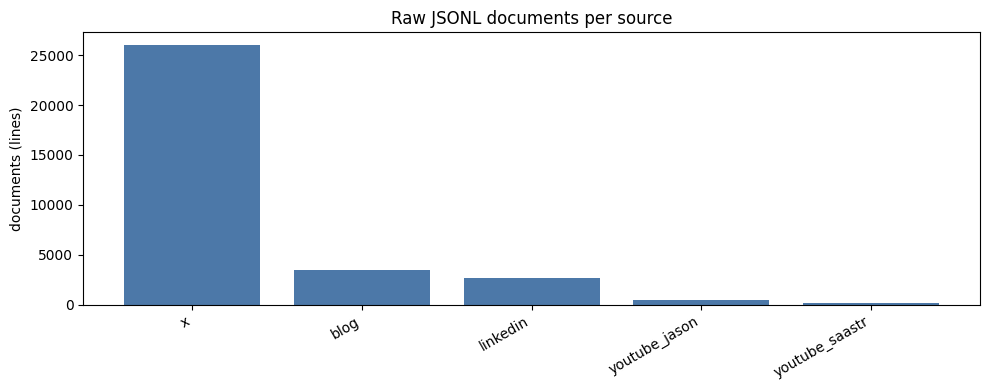

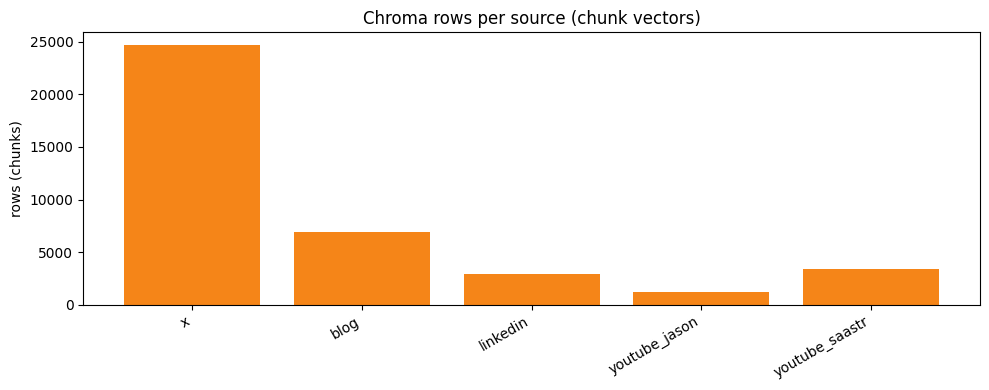

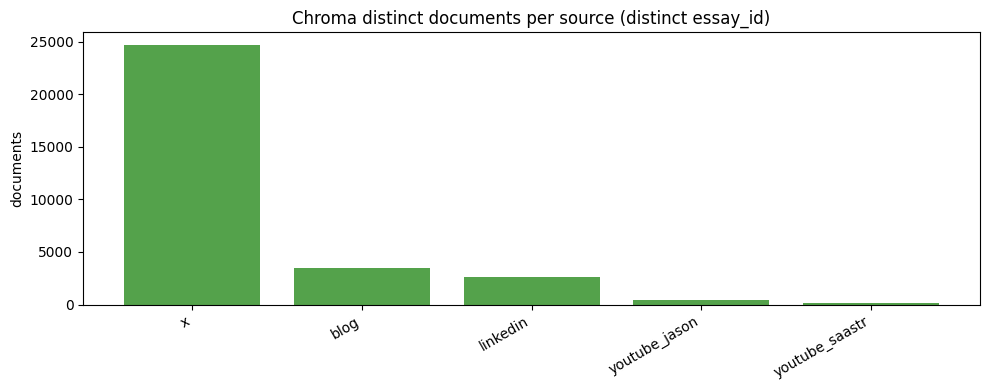

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(df["source"], df["raw_jsonl_lines"], color="#4C78A8")
plt.title("Raw JSONL documents per source")
plt.ylabel("documents (lines)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df["source"], df["chroma_chunk_rows"], color="#F58518")
plt.title("Chroma rows per source (chunk vectors)")
plt.ylabel("rows (chunks)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df["source"], df["chroma_distinct_essay_id"], color="#54A24B")
plt.title("Chroma distinct documents per source (distinct essay_id)")
plt.ylabel("documents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4.5 Pipeline Demo — what to show live / screenshots

### What to demo (recommended)

- **Airflow UI** (`http://localhost:8080`) 
  - Show DAG `lemkin_content_pipeline` in Grid view: `extract_to_minio → trigger_spark_clean → load_to_chroma` all green.
  - Open task logs and show:
    - `Uploaded N records from ...` (extract)
    - `Chunk rows: ...; with non-empty embedding: ...` + `Wrote to s3a://.../chunks/` (Spark)
    - `Chroma collection 'lemkin_content': upserted ...; skipped ...` (load)

- **MinIO Console** (`http://localhost:9001`) 
  - Browse `lemkin-raw/raw/` and `lemkin-processed/chunks/` to show lineage.

- **Chroma verification**
  - Run `previewchromadb.py` (or the notebook’s Chroma cells) to show:
    - rows per source (chunks)
    - distinct `essay_id` per source (documents)
    - 3 samples per source

- **Streamlit** (`http://localhost:8501`)
  - Ask a question and show retrieved context is coming from multiple sources.

### Notes (be explicit)

- This is a **retrieval + embedding** pipeline (RAG). There is no model training loop and no train/val/test split produced.
- Observability is primarily via **Airflow logs + MinIO browse + Chroma counts**.

## Data source descriptions (X, blog, LinkedIn, YouTube)

This section documents what each dataset contains, how it was collected, and key fields used downstream.

### Blog (`source='blog'`)
- Collected from **SaaStr** author archive pages and post pages.
- Raw file: `data/jasonlemkin_blog.jsonl` (one JSON per post).
- Core fields (typical): `title`, `date`, `url`, `content`.

### LinkedIn (`source='linkedin'`)
- Raw file: `data/jasonlemkinlinkedin.jsonl`.
- Core fields (typical): `content`, `published_text`.

### YouTube transcripts (`source='youtube_jason'` and `source='youtube_saastr'`)
- Raw files: `data/jasonmlemkinyoutubetranscripts.jsonl`, `data/saastryoutubetranscripts.jsonl`.
- Core fields (typical): `video_title`, `video_url`, `transcript_text`, `upload_date_iso`.

### X/Twitter (`source='x'`)
- Raw file: `data/jasonlk_originals.jsonl`.
- Core fields (typical): `text`, `created_at`, `url`, plus flags used for filtering.

**Note:** The Airflow DAG performs a *normalization* step that converts every source into a common schema: `{title, date, url, text, source}`. That unified schema is what Spark/Chroma sees.

In [13]:
# Show the most common keys per raw dataset to support "data description" claims.

def top_keys(path: Path, max_rows: int = 5000, top_n: int = 25):
    c = Counter()
    n = 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if n >= max_rows:
                break
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                c.update(obj.keys())
                n += 1
    return c.most_common(top_n), n

for fname in existing:
    p = DATA_DIR / fname
    keys, n = top_keys(p)
    print(f"\n=== {fname} (scanned {n} rows) ===")
    for k, cnt in keys[:15]:
        print(f"- {k}: present in {cnt} rows")


=== jasonlemkin_blog.jsonl (scanned 3502 rows) ===
- title: present in 3502 rows
- date: present in 3502 rows
- url: present in 3502 rows
- tags: present in 3502 rows
- content: present in 3502 rows
- scraped_at: present in 3502 rows

=== jasonlemkinlinkedin.jsonl (scanned 2675 rows) ===
- author: present in 2675 rows
- author_source: present in 2675 rows
- content: present in 2675 rows
- format: present in 2675 rows
- char_count: present in 2675 rows
- published_text: present in 2675 rows
- urn: present in 14 rows
- url: present in 14 rows

=== jasonmlemkinyoutubetranscripts.jsonl (scanned 462 rows) ===
- channel: present in 462 rows
- video_id: present in 462 rows
- video_title: present in 462 rows
- video_url: present in 462 rows
- matched_keywords: present in 462 rows
- transcript_text: present in 462 rows
- transcript_language: present in 462 rows
- transcript_segments_count: present in 462 rows
- transcript_error: present in 462 rows
- fetched_at_utc: present in 462 rows
- listi

## In-depth cleaning + validation (with real examples)

We replicate (in Python) the **same normalization and filters** as `dags/lemkin_pipeline_dag.py`, then show:

- **Before:** a raw JSONL row
- **After normalization:** `{title, date, url, text, source}`
- **After cleaning:** HTML stripped, whitespace normalized
- **Validation checks:** empty text, min-length rules, and (for X) reply/repost filters

This lets you screenshot concrete before/after transformations.

In [14]:
import re
from datetime import datetime
from bs4 import BeautifulSoup


def strip_html_bs(text: str) -> str:
    return BeautifulSoup(text or "", "html.parser").get_text(separator=" ")


def normalize_blog(row: dict) -> dict | None:
    text = (row.get("content") or row.get("text") or "").strip()
    if not text:
        return None
    title = (row.get("title") or "Blog post")[:500]
    return {
        "title": title,
        "date": row.get("date") or "",
        "url": row.get("url") or "",
        "text": text,
        "source": "blog",
    }


def normalize_linkedin(row: dict) -> dict | None:
    text = (row.get("content") or "").strip()
    if not text:
        return None
    short = text[:120] + ("..." if len(text) > 120 else "")
    return {
        "title": short,
        "date": row.get("published_text") or "",
        "url": "",
        "text": text,
        "source": "linkedin",
    }


def normalize_youtube(row: dict, source_tag: str) -> dict | None:
    text = (row.get("transcript_text") or "").strip()
    if not text:
        return None
    date = row.get("upload_date_iso") or ""
    if not date and row.get("fetched_at_utc"):
        date = str(row["fetched_at_utc"])[:10]
    return {
        "title": (row.get("video_title") or "YouTube video")[:500],
        "date": date,
        "url": row.get("video_url") or "",
        "text": text,
        "source": source_tag,
    }


def normalize_x(row: dict) -> dict | None:
    # Matches DAG logic
    if row.get("is_reply") or row.get("is_repost_or_quote"):
        return None
    text = (row.get("text") or "").strip()
    if len(text) < 25:
        return None
    preview = text[:120] + ("..." if len(text) > 120 else "")
    return {
        "title": preview,
        "date": row.get("created_at") or "",
        "url": row.get("url") or "",
        "text": text,
        "source": "x",
    }


def clean_normalized(rec: dict) -> dict:
    out = dict(rec)
    out["text_before_clean"] = out.get("text", "")
    out["text"] = strip_html_bs(out.get("text") or "")
    out["text"] = re.sub(r"\s+", " ", out["text"]).strip()
    return out


def load_first_valid(path: Path, normalizer, n_try: int = 5000):
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n_try:
                break
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if not isinstance(obj, dict):
                continue
            rec = normalizer(obj)
            if rec and (rec.get("text") or "").strip():
                return obj, rec
    return None, None

raw_example_map = {
    "jasonlemkin_blog.jsonl": (normalize_blog, None),
    "jasonlemkinlinkedin.jsonl": (normalize_linkedin, None),
    "jasonmlemkinyoutubetranscripts.jsonl": (lambda r: normalize_youtube(r, "youtube_jason"), None),
    "saastryoutubetranscripts.jsonl": (lambda r: normalize_youtube(r, "youtube_saastr"), None),
    "jasonlk_originals.jsonl": (normalize_x, None),
}

examples = {}
for fname in existing:
    norm_fn, _ = raw_example_map.get(fname, (None, None))
    if norm_fn is None:
        continue
    raw_row, norm_row = load_first_valid(DATA_DIR / fname, norm_fn)
    if raw_row is None:
        continue
    examples[fname] = {
        "raw": raw_row,
        "normalized": norm_row,
        "cleaned": clean_normalized(norm_row),
    }

list(examples.keys())

['jasonlemkin_blog.jsonl',
 'jasonlemkinlinkedin.jsonl',
 'jasonmlemkinyoutubetranscripts.jsonl',
 'saastryoutubetranscripts.jsonl',
 'jasonlk_originals.jsonl']

In [15]:
# Print deep before/after examples you can screenshot.
for fname, ex in examples.items():
    print("\n" + "=" * 90)
    print("FILE:", fname)
    print("--- RAW (truncated) ---")
    print(json.dumps(ex["raw"], ensure_ascii=False)[:1200])
    print("\n--- NORMALIZED (used by Spark) ---")
    print(json.dumps(ex["normalized"], ensure_ascii=False, indent=2)[:1200])
    print("\n--- CLEANED TEXT (HTML stripped + whitespace normalized) ---")
    cleaned = ex["cleaned"]
    print("text_before_clean[:400]:", cleaned["text_before_clean"][:400])
    print("text_after_clean[:400]: ", cleaned["text"][:400])


FILE: jasonlemkin_blog.jsonl
--- RAW (truncated) ---
{"title": "5 Ways to Turn Your Support Data Into a Customer Acquisition Channel with HappyFox’s Founder CEO", "date": "2026-03-24T10:19:09+00:00", "url": "https://www.saastr.com/5-ways-to-turn-your-support-data-into-a-customer-acquisition-channel-with-happyfoxs-founder-ceo/", "tags": [], "content": "Shalin Jain built HappyFox to $20M+ ARR, bootstrapped, with about 100 employees. He went from 5 support reps at $1M ARR to 6 support reps at $20M ARR. Same story on sales: 6 sellers at $3M, still 6 sellers at $20M. He recently shared how his team did it by treating support data as their primary GTM engine. Here are the 5 most actionable takeaways.\n1. Your Support Queue Already Has the Expansion Signals. You Just Need Something Reading Them.\nMost B2B companies treat expansion as a sales-led or CS-led motion. Shalin found the highest-ROI signals were already sitting in support tickets.\nCustomers mention needing more seats. They ask abou

## Build a unified (normalized) dataset locally

This creates a **preprocessed** table with one row per *document* across all sources:

- `source`, `title`, `date`, `url`, `text`
- `text_len_chars`, `text_len_words`

We then create a **transformed** table by chunking each document into ~500-word chunks (matching Spark’s intent).

Finally we build **prepared** train/val/test splits (per-source and combined).

In [16]:
import pandas as pd


def iter_jsonl(path: Path):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except Exception:
                continue
            if isinstance(obj, dict):
                yield obj


def build_normalized_docs(max_rows_per_file: int | None = None):
    out = []

    for fname in existing:
        p = DATA_DIR / fname
        if fname == "jasonlemkin_blog.jsonl":
            norm = normalize_blog
        elif fname == "jasonlemkinlinkedin.jsonl":
            norm = normalize_linkedin
        elif fname == "jasonmlemkinyoutubetranscripts.jsonl":
            norm = lambda r: normalize_youtube(r, "youtube_jason")
        elif fname == "saastryoutubetranscripts.jsonl":
            norm = lambda r: normalize_youtube(r, "youtube_saastr")
        elif fname == "jasonlk_originals.jsonl":
            norm = normalize_x
        else:
            continue

        kept = 0
        for i, row in enumerate(iter_jsonl(p)):
            if max_rows_per_file is not None and i >= max_rows_per_file:
                break
            rec = norm(row)
            if not rec:
                continue
            rec = clean_normalized(rec)
            if not rec.get("text"):
                continue
            rec["raw_file"] = fname
            rec["text_len_chars"] = len(rec["text"])
            rec["text_len_words"] = len(rec["text"].split())
            out.append(rec)
            kept += 1

        print(f"Normalized kept {kept:,} rows from {fname}")

    return pd.DataFrame(out)


docs = build_normalized_docs(max_rows_per_file=None)
docs.head(3)

Normalized kept 3,502 rows from jasonlemkin_blog.jsonl
Normalized kept 2,675 rows from jasonlemkinlinkedin.jsonl
Normalized kept 428 rows from jasonmlemkinyoutubetranscripts.jsonl
Normalized kept 194 rows from saastryoutubetranscripts.jsonl
Normalized kept 24,644 rows from jasonlk_originals.jsonl


,title,date,url,text,source,text_before_clean,raw_file,text_len_chars,text_len_words
0,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,"Shalin Jain built HappyFox to $20M+ ARR, boots...",blog,"Shalin Jain built HappyFox to $20M+ ARR, boots...",jasonlemkin_blog.jsonl,6945,1153
1,Dear SaaStr: Our CFO Sounds Very Polished but ...,2026-03-21T10:10:55+00:00,https://www.saastr.com/cfomissingburn/,Dear SaaStr: Our CFO sounds very polished but ...,blog,Dear SaaStr: Our CFO sounds very polished but ...,jasonlemkin_blog.jsonl,2699,471
2,Dear SaaStr: Can I Convert My Customer Success...,2026-03-26T10:12:45+00:00,https://www.saastr.com/dear-saastr-can-i-conve...,"Short answer: Only in very specific cases, and...",blog,"Short answer: Only in very specific cases, and...",jasonlemkin_blog.jsonl,2192,357


In [17]:
print("Preprocessed (normalized) documents:")
print(docs.groupby("source").size().sort_values(ascending=False).to_string())
print("\nTotal docs:", len(docs))

# Dedup check (Spark does this later; we show the impact here too)
dedup_cols = ["source", "title", "url", "text"]
docs_dedup = docs.drop_duplicates(subset=dedup_cols).copy()
print("\nAfter dedup on (source,title,url,text):")
print(docs_dedup.groupby("source").size().sort_values(ascending=False).to_string())
print("Total docs after dedup:", len(docs_dedup))

Preprocessed (normalized) documents:
source
x                 24644
blog               3502
linkedin           2675
youtube_jason       428
youtube_saastr      194

Total docs: 31443

After dedup on (source,title,url,text):
source
x                 24644
blog               3502
linkedin           2661
youtube_jason       426
youtube_saastr      194
Total docs after dedup: 31427


In [18]:
CHUNK_WORD_LIMIT = 500

def chunk_words(text: str, limit: int = CHUNK_WORD_LIMIT) -> list[str]:
    words = (text or "").split()
    return [" ".join(words[i:i+limit]) for i in range(0, len(words), limit) if words[i:i+limit]]

# Transformed dataset: one row per chunk
chunk_rows = []
for idx, r in docs_dedup.reset_index(drop=True).iterrows():
    chunks = chunk_words(r["text"], CHUNK_WORD_LIMIT)
    for ci, ct in enumerate(chunks):
        chunk_rows.append({
            "doc_idx": idx,
            "source": r["source"],
            "title": r["title"],
            "date": r["date"],
            "url": r["url"],
            "chunk_index": ci,
            "chunk_text": ct,
            "chunk_word_count": len(ct.split()),
        })

chunks = pd.DataFrame(chunk_rows)
print("Transformed chunk rows:", len(chunks))
chunks.head(3)

Transformed chunk rows: 39031


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
0,0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,0,"Shalin Jain built HappyFox to $20M+ ARR, boots...",500
1,0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,1,"a company gets acquired, the new leadership of...",500
2,0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,2,the table every week. Shalin ran all 8 of his ...,153


In [19]:
print("Chunks per source:")
print(chunks.groupby("source").size().sort_values(ascending=False).to_string())

# Show 2 real transformed rows (chunk records) for screenshots
for src in sorted(chunks["source"].unique()):
    print("\n--- Transformed chunk samples for", src, "---")
    display(chunks[chunks["source"] == src].head(2))

Chunks per source:
source
x                 24679
blog               6895
youtube_saastr     3413
linkedin           2878
youtube_jason      1166

--- Transformed chunk samples for blog ---


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
0,0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,0,"Shalin Jain built HappyFox to $20M+ ARR, boots...",500
1,0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,1,"a company gets acquired, the new leadership of...",500



--- Transformed chunk samples for linkedin ---


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
6895,3502,linkedin,"""As of today, attendee registrations for SaaSt...",2 hours ago,,0,"""As of today, attendee registrations for SaaSt...",55
6896,3503,linkedin,This year we churned off a vendor for SaaStr A...,5 hours ago,,0,This year we churned off a vendor for SaaStr A...,104



--- Transformed chunk samples for x ---


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
14352,6783,x,Everyone has an AI strategy. Almost nobody has...,2026-02-11T20:55:03.000Z,https://x.com/jasonlk/status/2021689460174594448,0,Everyone has an AI strategy. Almost nobody has...,54
14353,6784,x,"""The public markets just don't believe public ...",2026-03-31T10:12:00.000Z,https://x.com/jasonlk/status/2038922249294745929,0,"""The public markets just don't believe public ...",38



--- Transformed chunk samples for youtube_jason ---


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
9773,6163,youtube_jason,AI in Contact Centers: TAM Expansion or Labor ...,2026-03-27,https://www.youtube.com/watch?v=k3WH5BxF1i8,0,They're a they have their average customers re...,500
9774,6163,youtube_jason,AI in Contact Centers: TAM Expansion or Labor ...,2026-03-27,https://www.youtube.com/watch?v=k3WH5BxF1i8,1,Mart. There's going to be humans on phones and...,310



--- Transformed chunk samples for youtube_saastr ---


,doc_idx,source,title,date,url,chunk_index,chunk_text,chunk_word_count
10939,6589,youtube_saastr,AI Replaces Sales Jobs: Future of Sales with J...,2026-01-20,https://www.youtube.com/watch?v=VBE5a24tv8A,0,AI is replacing the jobs people don't want to ...,289
10940,6590,youtube_saastr,AI + B2B in 2026: Find the Tailwinds or Get Le...,2026-01-02,https://www.youtube.com/watch?v=RZYUn_ExLBY,0,Welcome to the official Saster Podcast where y...,500


## Train/Validation/Test splits (per source + combined)

Even though the Airflow pipeline is for **RAG retrieval** (not supervised training), this section creates reproducible splits to satisfy the rubric.

We split at the **document level** (post/video/x-item), then inherit those labels to the chunk rows.

- Default ratios: **80/10/10** (train/val/test)
- Deterministic: fixed random seed
- Per-source: split each `source` separately
- Combined: stratified by `source` (so each split contains all sources)


In [20]:
import numpy as np

RNG_SEED = 298
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
TEST_FRAC = 0.10
assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9


def add_doc_id(df: pd.DataFrame) -> pd.DataFrame:
    # Stable-ish ID: prefer url; fall back to a hash of (source,title,text)
    def make_id(r):
        u = (r.get("url") or "").strip()
        if u:
            return f"{r['source']}|{u}"
        s = f"{r['source']}|{r.get('title','')}|{r.get('text','')[:200]}"
        return f"{r['source']}|hash|{abs(hash(s))}"

    out = df.copy()
    out["doc_id"] = out.apply(make_id, axis=1)
    return out


def split_ids(ids: list[str], seed: int = RNG_SEED):
    ids = list(dict.fromkeys(ids))
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    n = len(ids)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    train = set(ids[:n_train])
    val = set(ids[n_train:n_train + n_val])
    test = set(ids[n_train + n_val:])
    return train, val, test


docs_for_split = add_doc_id(docs_dedup)

# Per-source splits
splits_per_source = {}
for src, g in docs_for_split.groupby("source"):
    train, val, test = split_ids(g["doc_id"].tolist(), seed=RNG_SEED)
    splits_per_source[src] = {"train": train, "val": val, "test": test}

# Combined stratified-by-source: union of per-source splits
combined = {"train": set(), "val": set(), "test": set()}
for src, s in splits_per_source.items():
    for k in combined:
        combined[k] |= s[k]

# Attach split labels

def label_split(doc_id: str, split_sets: dict[str, set]):
    for k in ("train", "val", "test"):
        if doc_id in split_sets[k]:
            return k
    return "unassigned"


docs_for_split["split_per_source"] = docs_for_split.apply(lambda r: label_split(r["doc_id"], splits_per_source[r["source"]]), axis=1)
docs_for_split["split_combined"] = docs_for_split["doc_id"].apply(lambda d: label_split(d, combined))

# Join doc splits onto chunks
chunks_with_split = chunks.merge(
    docs_for_split[["doc_id", "source", "split_per_source", "split_combined"]].reset_index().rename(columns={"index": "doc_idx"}),
    on=["doc_idx", "source"],
    how="left",
)

print("Per-source split sizes (documents):")
for src in sorted(splits_per_source.keys()):
    s = splits_per_source[src]
    print(f"- {src}: train={len(s['train'])} val={len(s['val'])} test={len(s['test'])}")

print("\nCombined split sizes (documents):", {k: len(v) for k, v in combined.items()})

print("\nCheck combined split composition by source:")
print(docs_for_split.groupby(["source", "split_combined"]).size().unstack(fill_value=0))

Per-source split sizes (documents):
- blog: train=2802 val=350 test=350
- linkedin: train=1697 val=212 test=212
- x: train=19715 val=2464 test=2465
- youtube_jason: train=341 val=43 test=42
- youtube_saastr: train=155 val=19 test=20

Combined split sizes (documents): {'train': 24710, 'val': 3088, 'test': 3089}

Check combined split composition by source:
split_combined  test  train   val
source                           
blog             350   2802   350
linkedin         290   2116   255
x               2465  19715  2464
youtube_jason     42    341    43
youtube_saastr    20    155    19


In [21]:
# Show 3 samples from each split for each dataset (documents)

def show_doc_samples(df: pd.DataFrame, split_col: str, n: int = 3):
    for split in ["train", "val", "test"]:
        sample = df[df[split_col] == split].head(n)
        print(f"\n=== {split_col}={split} ({len(sample)} sample rows shown) ===")
        display(sample[["source", "title", "date", "url", "text_len_words", "doc_id"]].head(n))

print("\nPer-source: blog")
show_doc_samples(docs_for_split[docs_for_split["source"] == "blog"], "split_per_source")

print("\nPer-source: linkedin")
show_doc_samples(docs_for_split[docs_for_split["source"] == "linkedin"], "split_per_source")

print("\nPer-source: youtube_jason")
show_doc_samples(docs_for_split[docs_for_split["source"] == "youtube_jason"], "split_per_source")

print("\nPer-source: youtube_saastr")
show_doc_samples(docs_for_split[docs_for_split["source"] == "youtube_saastr"], "split_per_source")

print("\nPer-source: x")
show_doc_samples(docs_for_split[docs_for_split["source"] == "x"], "split_per_source")

print("\nCombined (all sources):")
show_doc_samples(docs_for_split, "split_combined")


Per-source: blog

=== split_per_source=train (3 sample rows shown) ===


,source,title,date,url,text_len_words,doc_id
1,blog,Dear SaaStr: Our CFO Sounds Very Polished but ...,2026-03-21T10:10:55+00:00,https://www.saastr.com/cfomissingburn/,471,blog|https://www.saastr.com/cfomissingburn/
2,blog,Dear SaaStr: Can I Convert My Customer Success...,2026-03-26T10:12:45+00:00,https://www.saastr.com/dear-saastr-can-i-conve...,357,blog|https://www.saastr.com/dear-saastr-can-i-...
3,blog,Dear SaaStr: How Long Does It Take to Deploy a...,2026-03-25T09:58:01+00:00,https://www.saastr.com/dear-saastr-how-long-do...,568,blog|https://www.saastr.com/dear-saastr-how-lo...



=== split_per_source=val (3 sample rows shown) ===


,source,title,date,url,text_len_words,doc_id
8,blog,SaaStr AI App of the Week: Launchpad.io — The ...,2026-03-21T11:57:53+00:00,https://www.saastr.com/saastr-ai-app-of-the-we...,1469,blog|https://www.saastr.com/saastr-ai-app-of-t...
15,blog,10 Things to Know Before You Deploy Your First...,2026-03-15T14:10:54+00:00,https://www.saastr.com/10-things-to-know-befor...,2571,blog|https://www.saastr.com/10-things-to-know-...
16,blog,20VC x SaaStr This Week: Anthropic Sues the Go...,2026-03-13T16:29:24+00:00,https://www.saastr.com/20vc-x-saastr-this-week...,2675,blog|https://www.saastr.com/20vc-x-saastr-this...



=== split_per_source=test (3 sample rows shown) ===


...

,source,title,date,url,text_len_words,doc_id
1,blog,Dear SaaStr: Our CFO Sounds Very Polished but ...,2026-03-21T10:10:55+00:00,https://www.saastr.com/cfomissingburn/,471,blog|https://www.saastr.com/cfomissingburn/
2,blog,Dear SaaStr: Can I Convert My Customer Success...,2026-03-26T10:12:45+00:00,https://www.saastr.com/dear-saastr-can-i-conve...,357,blog|https://www.saastr.com/dear-saastr-can-i-...
3,blog,Dear SaaStr: How Long Does It Take to Deploy a...,2026-03-25T09:58:01+00:00,https://www.saastr.com/dear-saastr-how-long-do...,568,blog|https://www.saastr.com/dear-saastr-how-lo...



=== split_combined=val (3 sample rows shown) ===


,source,title,date,url,text_len_words,doc_id
8,blog,SaaStr AI App of the Week: Launchpad.io — The ...,2026-03-21T11:57:53+00:00,https://www.saastr.com/saastr-ai-app-of-the-we...,1469,blog|https://www.saastr.com/saastr-ai-app-of-t...
15,blog,10 Things to Know Before You Deploy Your First...,2026-03-15T14:10:54+00:00,https://www.saastr.com/10-things-to-know-befor...,2571,blog|https://www.saastr.com/10-things-to-know-...
16,blog,20VC x SaaStr This Week: Anthropic Sues the Go...,2026-03-13T16:29:24+00:00,https://www.saastr.com/20vc-x-saastr-this-week...,2675,blog|https://www.saastr.com/20vc-x-saastr-this...



=== split_combined=test (3 sample rows shown) ===


,source,title,date,url,text_len_words,doc_id
0,blog,5 Ways to Turn Your Support Data Into a Custom...,2026-03-24T10:19:09+00:00,https://www.saastr.com/5-ways-to-turn-your-sup...,1153,blog|https://www.saastr.com/5-ways-to-turn-you...
53,blog,How Big of a Sales Team Do You Really Need at ...,2026-03-04T15:10:16+00:00,https://www.saastr.com/how-big-of-a-sales-team...,2408,blog|https://www.saastr.com/how-big-of-a-sales...
55,blog,"If You’re Behind on AI, Put Your 10-20 Best En...",2026-03-05T15:10:46+00:00,https://www.saastr.com/if-youre-behind-on-ai-p...,1329,blog|https://www.saastr.com/if-youre-behind-on...


## Data statistics, imbalance, and drift/baseline checks

We compute:

- **Counts** at each stage (raw → preprocessed → transformed → prepared)
- **Distributions**: document length, chunk length
- **Imbalance**: per-source dominance
- **Drift (lightweight)**: compare early vs late documents by available date strings; if dates are missing/unparseable, we fall back to a random split baseline.

These are basic checks suitable for a presentation; they’re not a full monitoring system.

In [22]:
# Summary table: raw -> preprocessed -> transformed -> prepared
# (This is the key accountability table for your slides.)

# Raw stage: JSONL line counts (documents)
raw_stage = pd.DataFrame(
    [{"source": raw_to_source[fname], "raw_jsonl_lines": int(n)} for fname, n in raw_counts.items()]
)
raw_stage = raw_stage.groupby("source", as_index=False)["raw_jsonl_lines"].sum()

# Preprocessed stage: normalized docs (after filters + HTML strip), before Spark-like dedup
pre_stage = docs.groupby("source", as_index=False).size().rename(columns={"size": "preprocessed_docs"})

# Transformed stage: after Spark-like dedup, then chunked
trans_docs_stage = docs_dedup.groupby("source", as_index=False).size().rename(columns={"size": "dedup_docs"})
trans_chunks_stage = chunks.groupby("source", as_index=False).size().rename(columns={"size": "chunk_rows"})

# Prepared stage: split sizes (document grain)
prep = (
    docs_for_split.groupby(["source", "split_combined"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(
        columns={
            "train": "prepared_train_docs",
            "val": "prepared_val_docs",
            "test": "prepared_test_docs",
        }
    )
)

summary_counts = raw_stage.merge(pre_stage, on="source", how="outer")
summary_counts = summary_counts.merge(trans_docs_stage, on="source", how="outer")
summary_counts = summary_counts.merge(trans_chunks_stage, on="source", how="outer")
summary_counts = summary_counts.merge(prep, on="source", how="outer")
summary_counts = summary_counts.fillna(0)

# Add a total row for slides
summary_total = pd.DataFrame(
    [
        {
            "source": "TOTAL",
            "raw_jsonl_lines": int(summary_counts["raw_jsonl_lines"].sum()),
            "preprocessed_docs": int(summary_counts["preprocessed_docs"].sum()),
            "dedup_docs": int(summary_counts["dedup_docs"].sum()),
            "chunk_rows": int(summary_counts["chunk_rows"].sum()),
            "prepared_train_docs": int(summary_counts.get("prepared_train_docs", pd.Series([0])).sum()),
            "prepared_val_docs": int(summary_counts.get("prepared_val_docs", pd.Series([0])).sum()),
            "prepared_test_docs": int(summary_counts.get("prepared_test_docs", pd.Series([0])).sum()),
        }
    ]
)

summary_counts_slides = pd.concat([summary_counts, summary_total], ignore_index=True)
summary_counts_slides

,source,raw_jsonl_lines,preprocessed_docs,dedup_docs,chunk_rows,prepared_test_docs,prepared_train_docs,prepared_val_docs
0,blog,3502,3502,3502,6895,350,2802,350
1,linkedin,2675,2675,2661,2878,290,2116,255
2,x,25997,24644,24644,24679,2465,19715,2464
3,youtube_jason,462,428,426,1166,42,341,43
4,youtube_saastr,199,194,194,3413,20,155,19


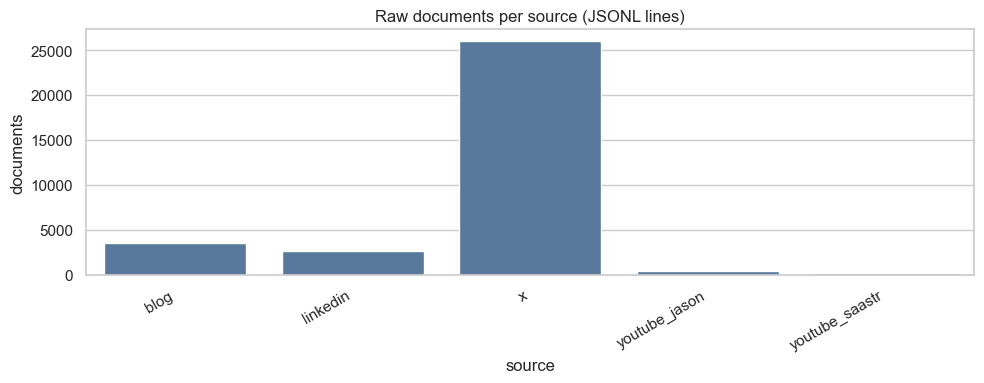

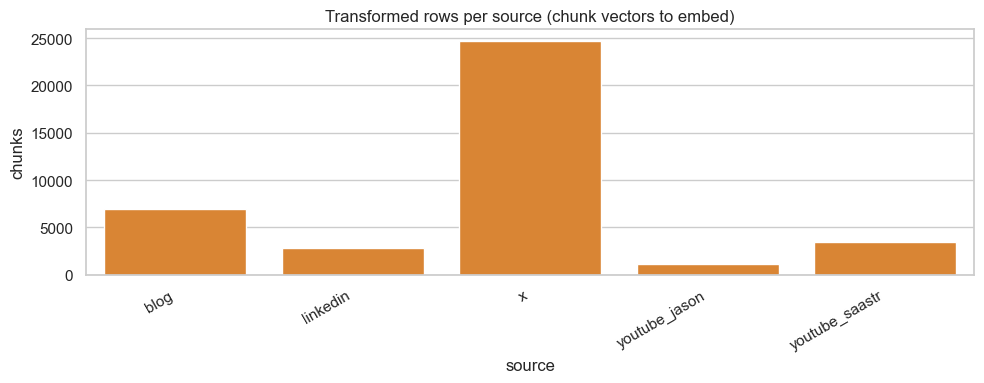

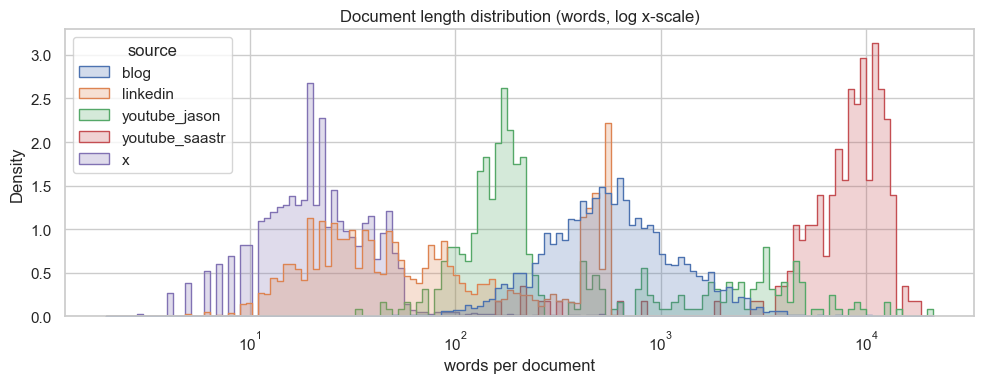

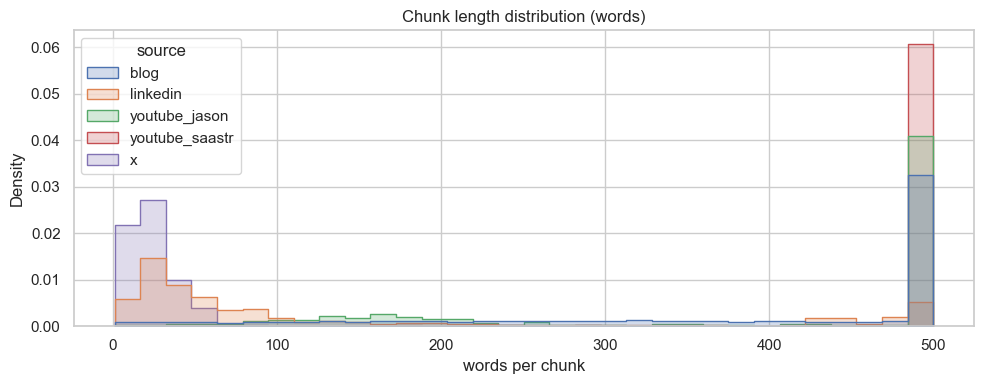

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Counts / imbalance
plt.figure(figsize=(10, 4))
sns.barplot(data=summary_counts, x="source", y="raw_jsonl_lines", color="#4C78A8")
plt.title("Raw documents per source (JSONL lines)")
plt.ylabel("documents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=summary_counts, x="source", y="chunk_rows", color="#F58518")
plt.title("Transformed rows per source (chunk rows to embed)")
plt.ylabel("chunks")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Document length distributions
plt.figure(figsize=(10, 4))
sns.histplot(
    data=docs_dedup,
    x="text_len_words",
    hue="source",
    element="step",
    stat="density",
    common_norm=False,
    log_scale=(True, False),
)
plt.title("Document length distribution (words, log x-scale)")
plt.xlabel("words per document")
plt.tight_layout()
plt.show()

# Chunk length sanity check + better visualization
max_chunk = int(chunks["chunk_word_count"].max()) if len(chunks) else 0
n_over = int((chunks["chunk_word_count"] > CHUNK_WORD_LIMIT).sum()) if len(chunks) else 0
print(f"Max chunk_word_count={max_chunk}; chunks > {CHUNK_WORD_LIMIT} words={n_over}")

# Zoomed histogram (0..CHUNK_WORD_LIMIT + small margin)
plt.figure(figsize=(10, 4))
sns.histplot(
    data=chunks,
    x="chunk_word_count",
    hue="source",
    bins=min(60, CHUNK_WORD_LIMIT + 20),
    element="step",
    stat="density",
    common_norm=False,
)
plt.xlim(0, CHUNK_WORD_LIMIT + 20)
plt.title(f"Chunk length distribution (zoomed to 0..{CHUNK_WORD_LIMIT + 20} words)")
plt.xlabel("words per chunk")
plt.tight_layout()
plt.show()

# ECDF makes differences visible even when most points pile at 500
plt.figure(figsize=(10, 4))
sns.ecdfplot(data=chunks, x="chunk_word_count", hue="source")
plt.xlim(0, CHUNK_WORD_LIMIT + 20)
plt.title("Chunk length ECDF (zoomed)")
plt.xlabel("words per chunk")
plt.tight_layout()
plt.show()

# If there is a tail (unexpected >500), visualize it separately
if n_over > 0:
    tail = chunks[chunks["chunk_word_count"] > CHUNK_WORD_LIMIT].copy()
    display(tail.sort_values("chunk_word_count", ascending=False).head(10))
    plt.figure(figsize=(10, 3))
    sns.histplot(data=tail, x="chunk_word_count", bins=30)
    plt.title(f"Tail: chunks with > {CHUNK_WORD_LIMIT} words")
    plt.xlabel("words per chunk")
    plt.tight_layout()
    plt.show()

In [25]:
# Lightweight drift/baseline check: compare early vs late docs by parsed date.
# Fix: normalize all parsed datetimes to *timezone-naive UTC* so pandas can sort.

from datetime import timezone
from dateutil import parser as dateparser


def try_parse_date_utc_naive(s: str):
    s = (s or "").strip()
    if not s:
        return None
    try:
        dt = dateparser.parse(s, fuzzy=True)
        if dt is None:
            return None
        if dt.tzinfo is not None:
            dt = dt.astimezone(timezone.utc).replace(tzinfo=None)
        return dt
    except Exception:
        return None


docs_drift = docs_dedup.copy()
docs_drift["date_parsed"] = docs_drift["date"].apply(try_parse_date_utc_naive)

usable = docs_drift[docs_drift["date_parsed"].notna()].copy()
print("Docs with parseable dates:", len(usable), "/", len(docs_dedup))

if len(usable) >= 100:
    usable = usable.sort_values("date_parsed")
    mid = len(usable) // 2
    early = usable.iloc[:mid]
    late = usable.iloc[mid:]

    def summarize(group: pd.DataFrame, name: str):
        return pd.DataFrame(
            {
                "group": [name],
                "n_docs": [len(group)],
                "mean_words": [group["text_len_words"].mean()],
                "p50_words": [group["text_len_words"].median()],
                "p90_words": [group["text_len_words"].quantile(0.90)],
            }
        )

    drift_summary = pd.concat([
        summarize(early, "early"),
        summarize(late, "late"),
    ])
    display(drift_summary)

    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=early, x="text_len_words", label="early", log_scale=True)
    sns.kdeplot(data=late, x="text_len_words", label="late", log_scale=True)
    plt.title("Drift check: document length distribution (early vs late, log x)")
    plt.xlabel("words per document")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough parseable dates for a time-based drift check. Use as a baseline only.")

Docs with parseable dates: 31423 / 31427


TypeError: can't compare offset-naive and offset-aware datetimes